In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

# Plot style
plt.style.use('ggplot')

In [34]:
df = pd.read_csv("data/heart_failure_clinical_records_dataset.csv")

## Data Quality Assessment

The dataset was inspected for:

- Missing values
- Duplicate records
- Invalid categorical values
- Summary statistics
- Potential inconsistencies

These checks ensure the dataset is reliable before proceeding to visualization and analysis.

In [35]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [36]:
df.shape

(299, 13)

In [37]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

In [38]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
                             ...   
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
Length: 13, dtype: object

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [40]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
                           ..
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
Length: 13, dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.nunique()

age                          47
anaemia                       2
creatinine_phosphokinase    208
diabetes                      2
ejection_fraction            17
                           ... 
serum_sodium                 27
sex                           2
smoking                       2
time                        148
DEATH_EVENT                   2
Length: 13, dtype: int64

In [43]:
categorical_cols = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "DEATH_EVENT"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


anaemia
anaemia
0    170
1    129
Name: count, dtype: int64

diabetes
diabetes
0    174
1    125
Name: count, dtype: int64

high_blood_pressure
high_blood_pressure
0    194
1    105
Name: count, dtype: int64

sex
sex
1    194
0    105
Name: count, dtype: int64

smoking
smoking
0    203
1     96
Name: count, dtype: int64

DEATH_EVENT
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
...,...,...,...,...,...,...,...,...
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0
smoking,299.0,0.321070,0.467670,0.0,0.0,0.0,1.0,1.0
time,299.0,130.260870,77.614208,4.0,73.0,115.0,203.0,285.0


## Univariate Analysis

In this section, each feature is analyzed independently to understand its distribution, spread, and potential anomalies.

The analysis includes:

- Summary statistics
- Histograms
- Boxplots
- Frequency distributions for categorical variables

This provides an overview of the dataset before examining relationships between variables.

In [45]:
numerical_cols = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

categorical_cols = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking',
    'DEATH_EVENT'
]

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']

Categorical Columns:
['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']


In [46]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
time,299.0,130.260870,77.614208,4.0,73.0,115.0,203.0,285.0


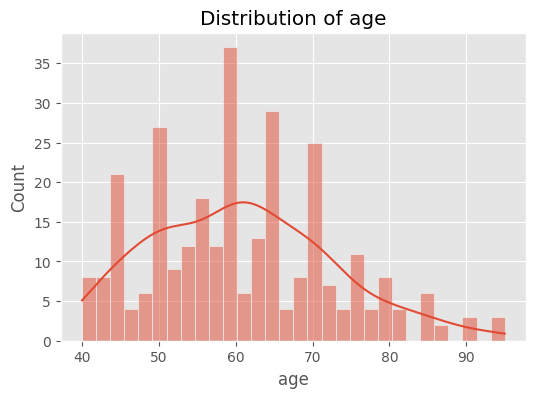

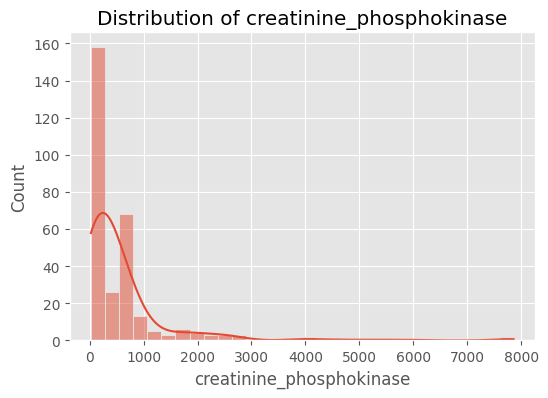

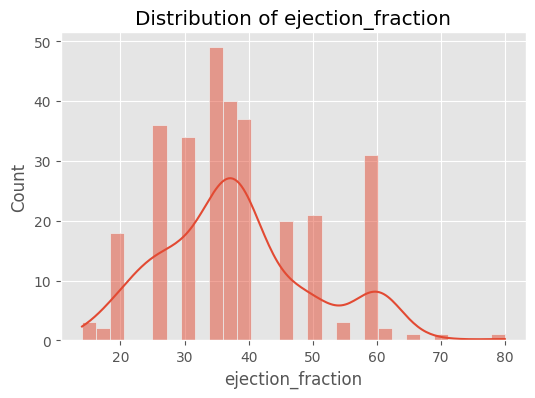

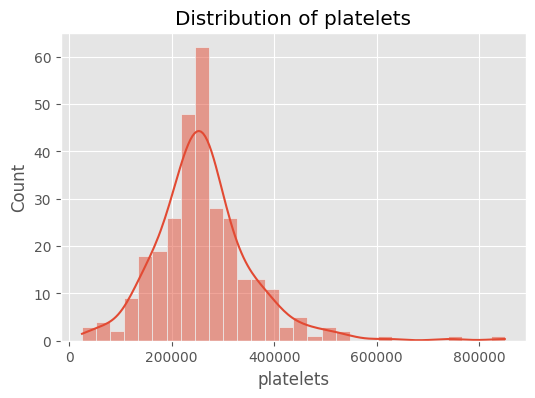

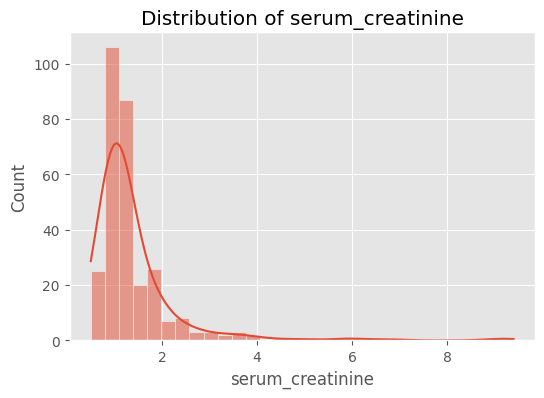

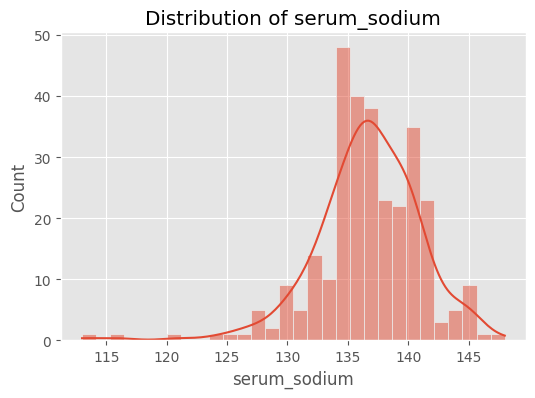

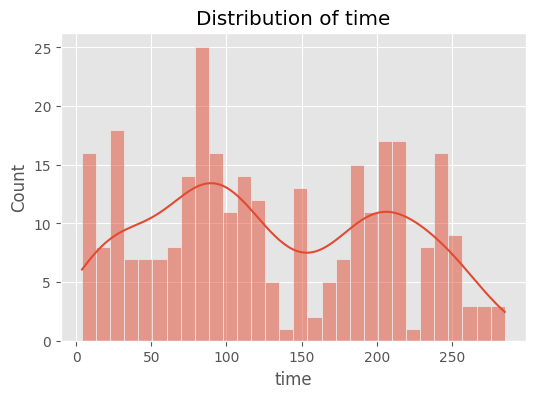

In [47]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

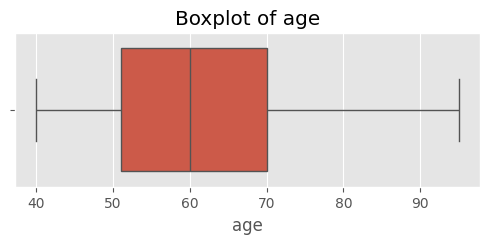

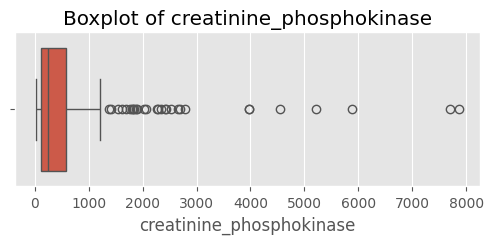

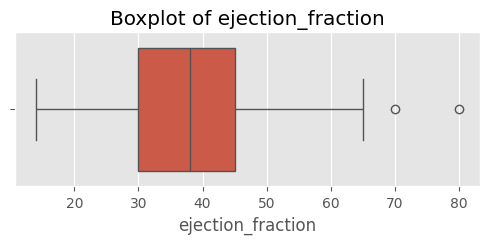

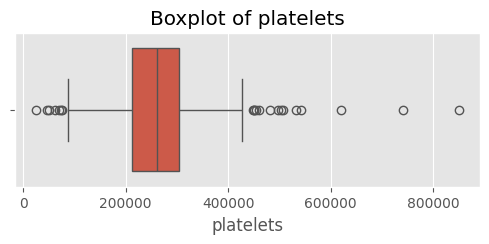

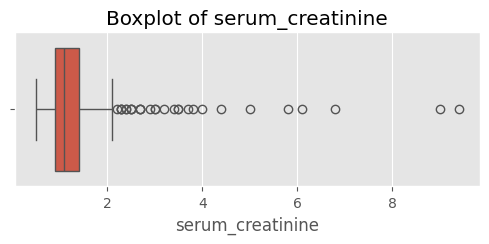

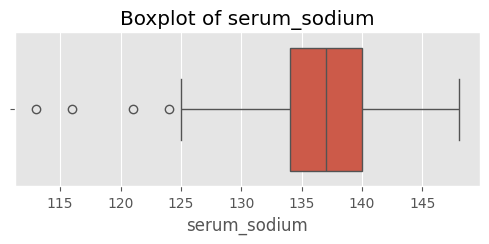

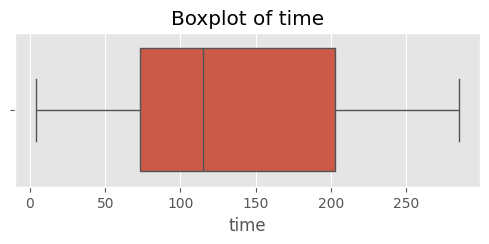

In [48]:
for col in numerical_cols:
    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

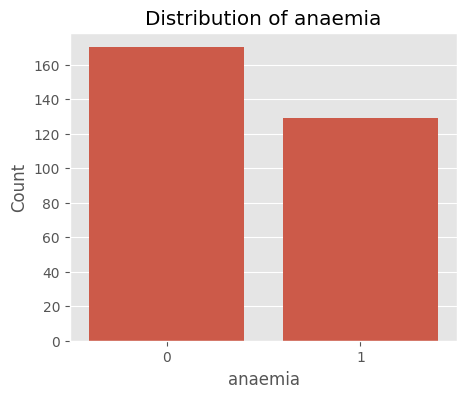

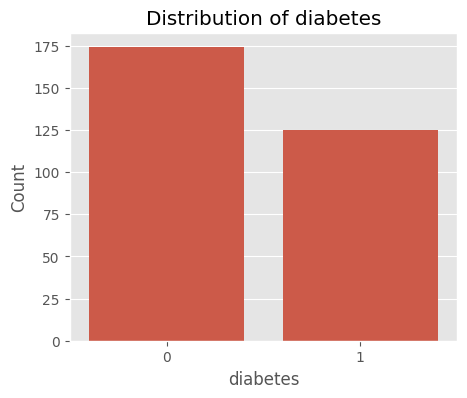

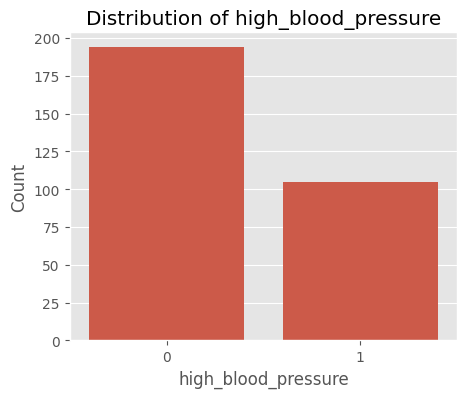

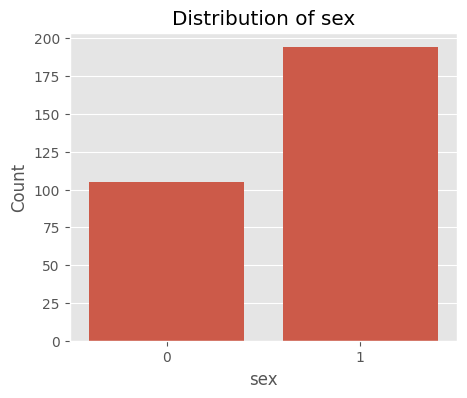

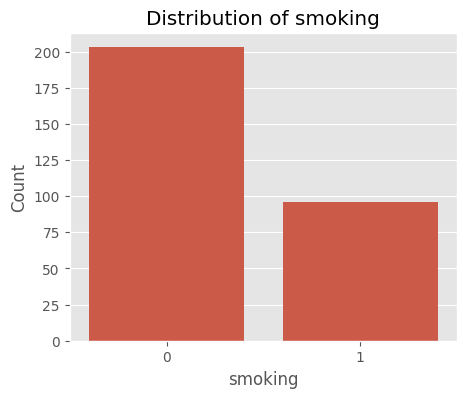

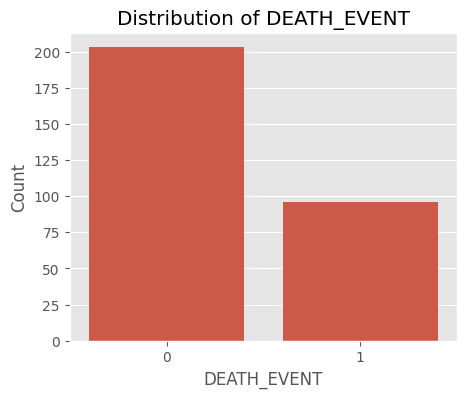

In [49]:
for col in categorical_cols:
    plt.figure(figsize=(5,4))

    sns.countplot(x=df[col])

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

In [50]:
for col in categorical_cols:
    print(f"\n{col}")
    print((df[col].value_counts(normalize=True)*100).round(2))


anaemia
anaemia
0    56.86
1    43.14
Name: proportion, dtype: float64

diabetes
diabetes
0    58.19
1    41.81
Name: proportion, dtype: float64

high_blood_pressure
high_blood_pressure
0    64.88
1    35.12
Name: proportion, dtype: float64

sex
sex
1    64.88
0    35.12
Name: proportion, dtype: float64

smoking
smoking
0    67.89
1    32.11
Name: proportion, dtype: float64

DEATH_EVENT
DEATH_EVENT
0    67.89
1    32.11
Name: proportion, dtype: float64


## Bivariate Analysis

Bivariate analysis examines the relationship between two variables. In this section, we investigate:

- Correlation between numerical variables
- Relationship between numerical variables and the target
- Relationship between categorical variables and the target
- Differences in feature distributions between survival outcomes

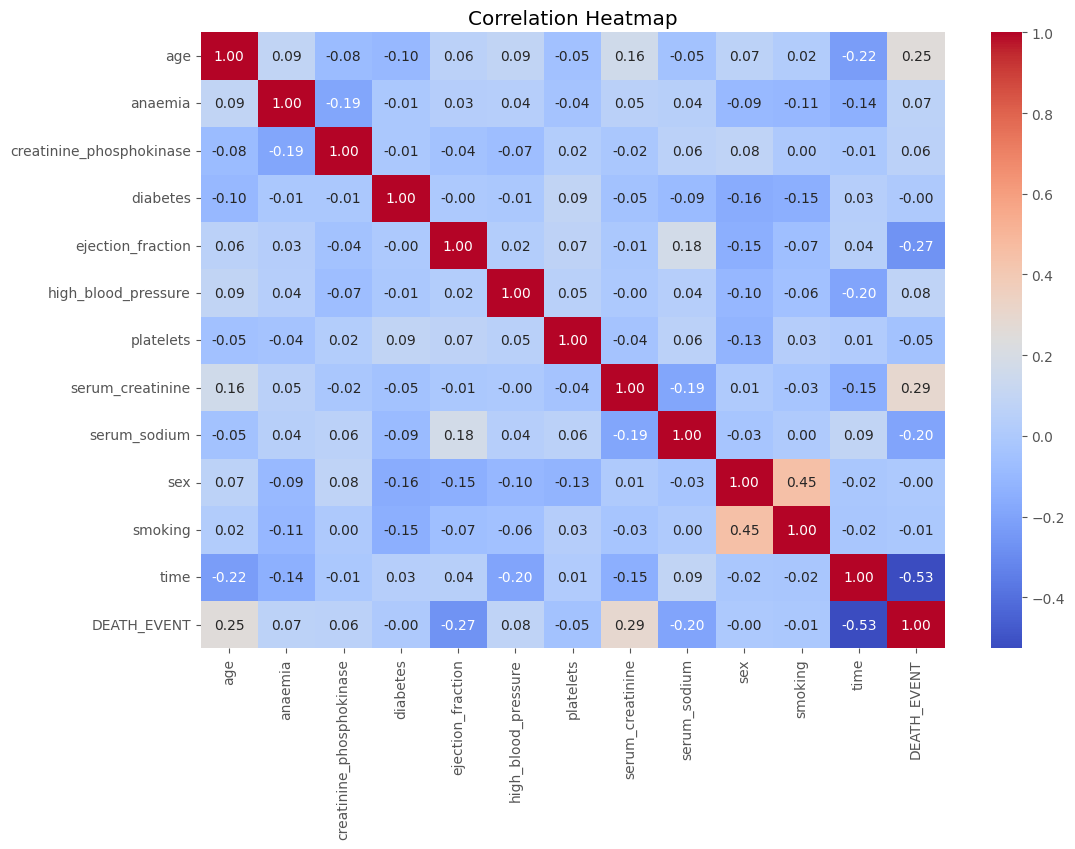

In [51]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [52]:
corr_target = corr["DEATH_EVENT"].sort_values(ascending=False)

corr_target

DEATH_EVENT            1.000000
serum_creatinine       0.294278
age                    0.253729
high_blood_pressure    0.079351
anaemia                0.066270
                         ...   
smoking               -0.012623
platelets             -0.049139
serum_sodium          -0.195204
ejection_fraction     -0.268603
time                  -0.526964
Name: DEATH_EVENT, Length: 13, dtype: float64

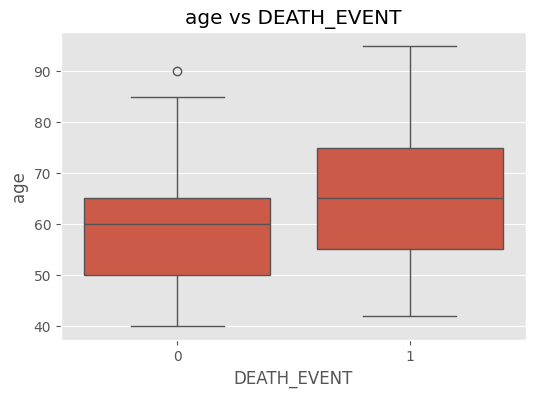

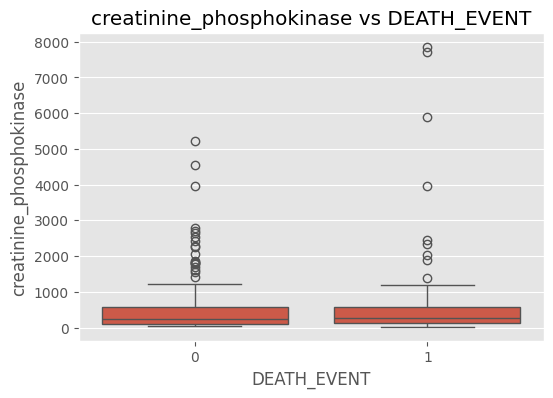

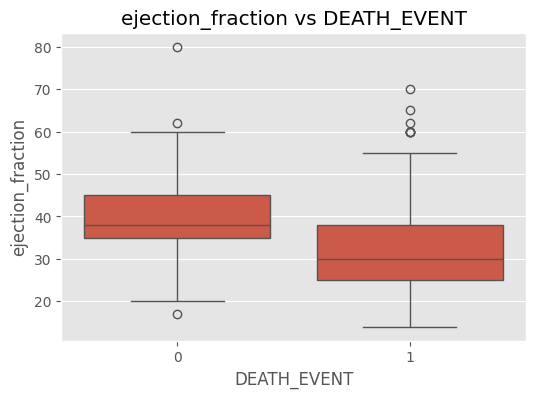

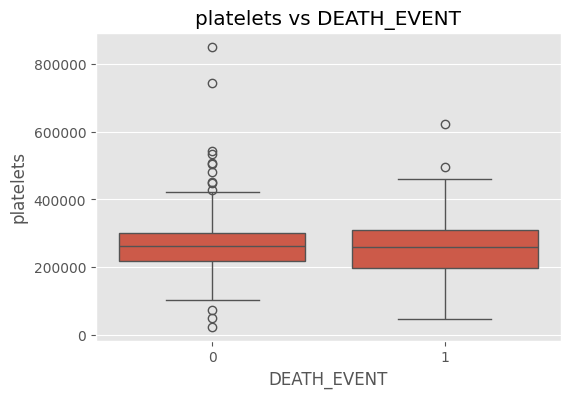

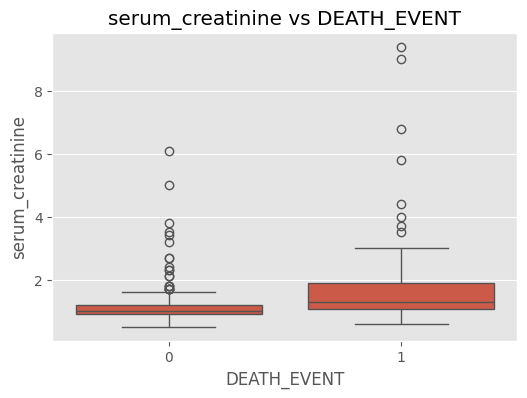

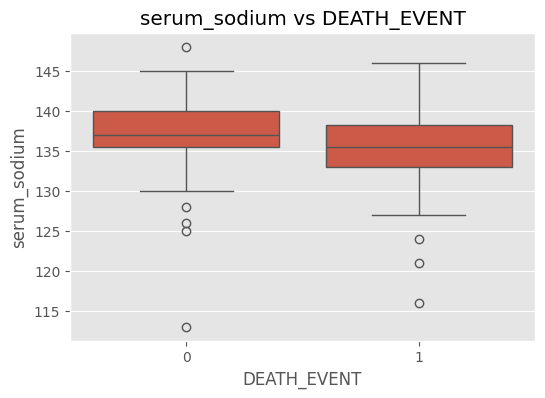

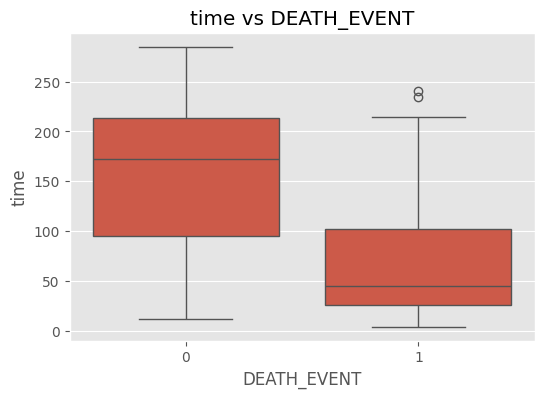

In [53]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="DEATH_EVENT",
        y=col,
        data=df
    )

    plt.title(f"{col} vs DEATH_EVENT")

    plt.show()

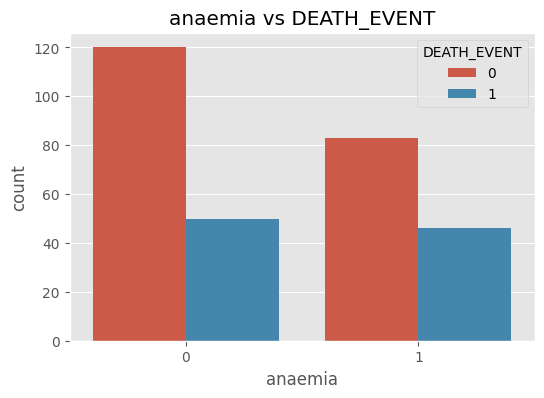

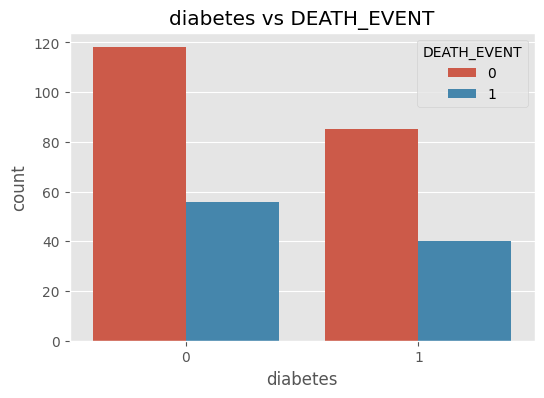

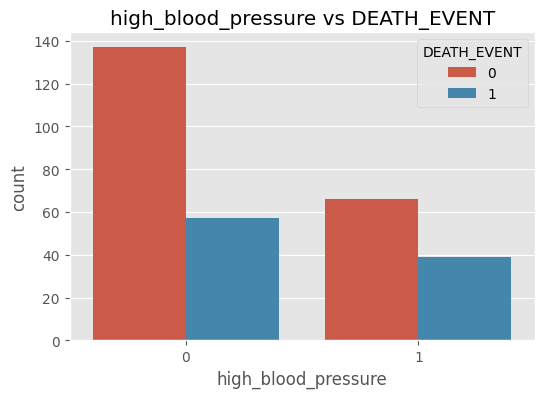

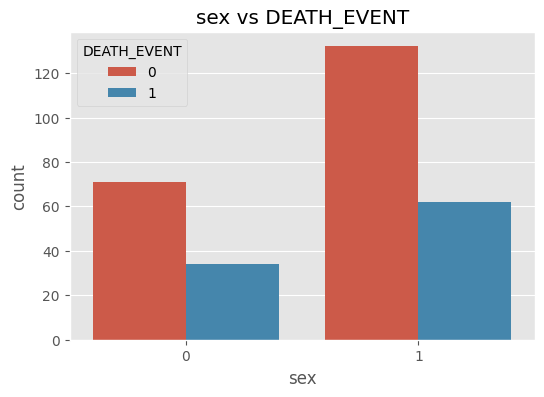

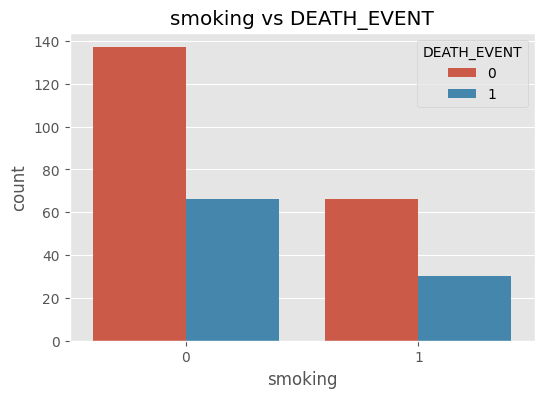

In [54]:
for col in categorical_cols[:-1]:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        hue="DEATH_EVENT",
        data=df
    )

    plt.title(f"{col} vs DEATH_EVENT")

    plt.show()

In [55]:
df.groupby("DEATH_EVENT")[numerical_cols].mean().T

DEATH_EVENT,0,1
age,58.761906,65.215281
creatinine_phosphokinase,540.054187,670.197917
ejection_fraction,40.266010,33.468750
platelets,266657.489901,256381.044792
serum_creatinine,1.184877,1.835833
serum_sodium,137.216749,135.375000
time,158.339901,70.885417


In [56]:
for col in categorical_cols[:-1]:

    print(f"\n===== {col} =====")

    print(
        pd.crosstab(
            df[col],
            df["DEATH_EVENT"],
            normalize="index"
        )*100
    )


===== anaemia =====
DEATH_EVENT          0          1
anaemia                          
0            70.588235  29.411765
1            64.341085  35.658915

===== diabetes =====
DEATH_EVENT          0          1
diabetes                         
0            67.816092  32.183908
1            68.000000  32.000000

===== high_blood_pressure =====
DEATH_EVENT                  0          1
high_blood_pressure                      
0                    70.618557  29.381443
1                    62.857143  37.142857

===== sex =====
DEATH_EVENT          0          1
sex                              
0            67.619048  32.380952
1            68.041237  31.958763

===== smoking =====
DEATH_EVENT          0          1
smoking                          
0            67.487685  32.512315
1            68.750000  31.250000


## Multivariate Analysis

Multivariate analysis explores interactions among multiple variables simultaneously. This section includes:

- Pairwise relationships
- Feature interactions with the target
- Distribution comparisons
- Insights useful for machine learning

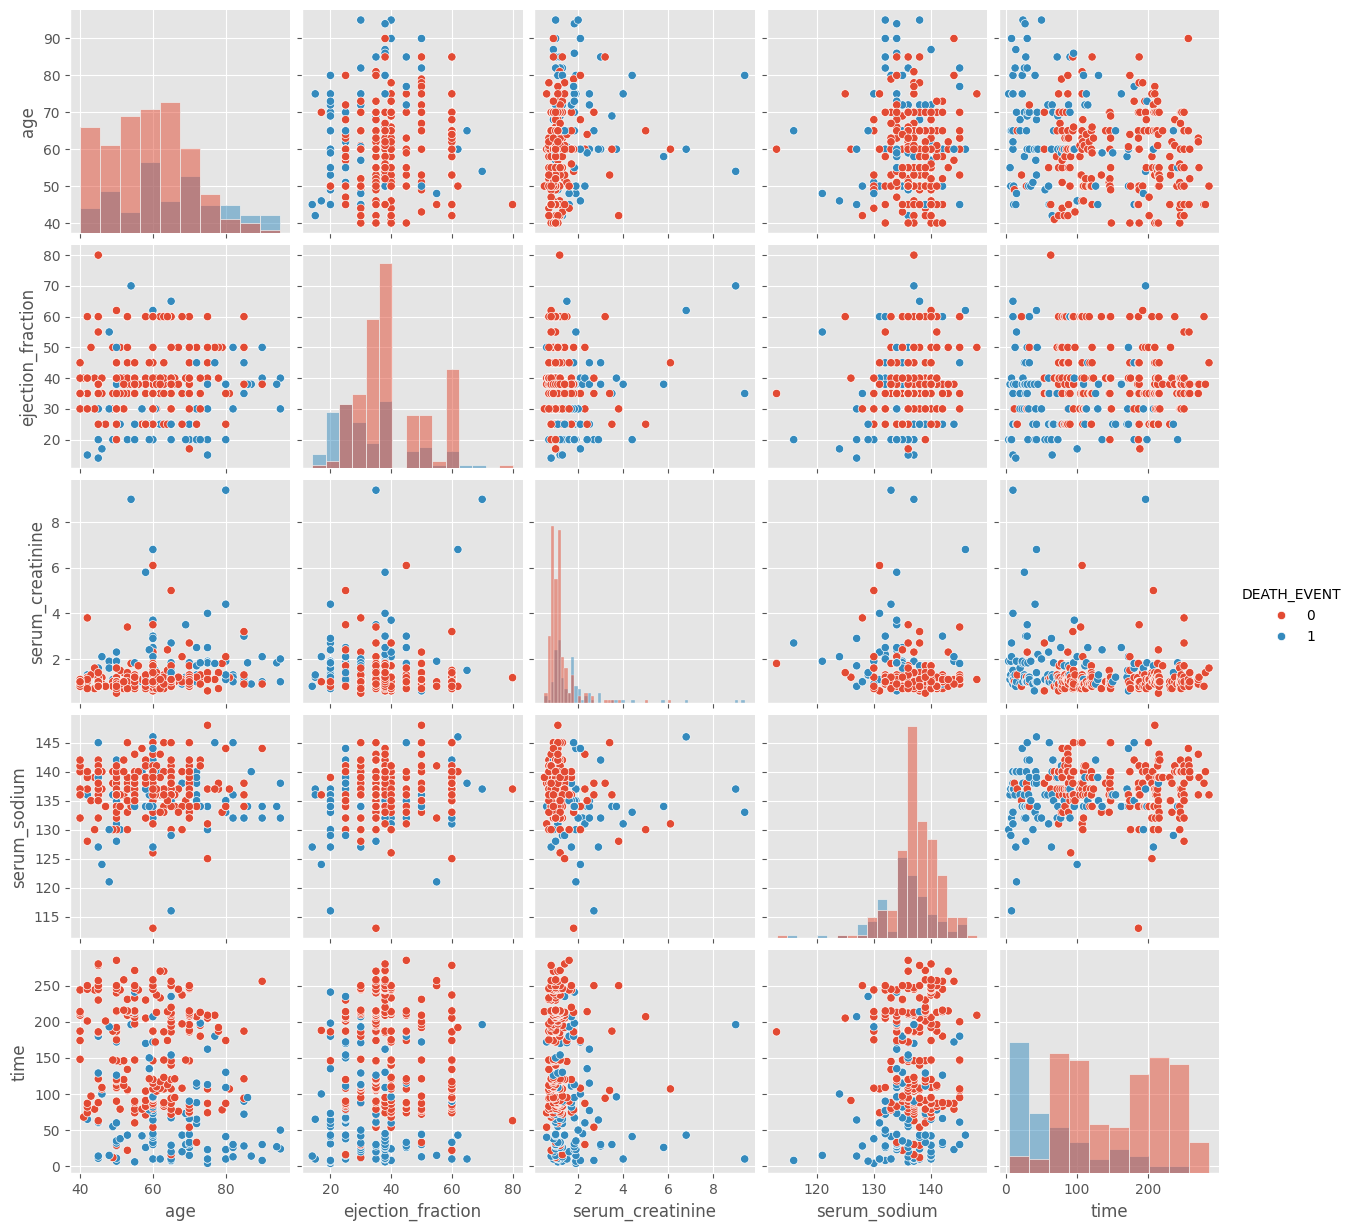

In [57]:
important_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "DEATH_EVENT"
]

sns.pairplot(
    df[important_features],
    hue="DEATH_EVENT",
    diag_kind="hist"
)

plt.show()

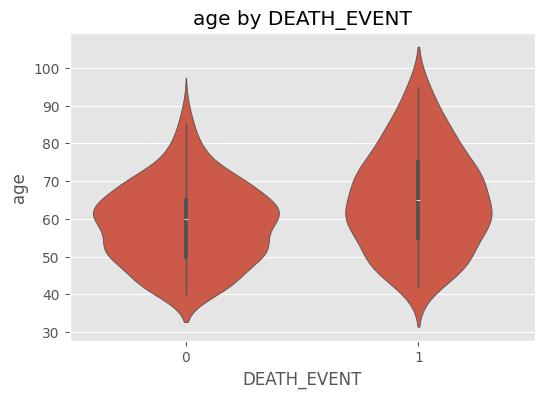

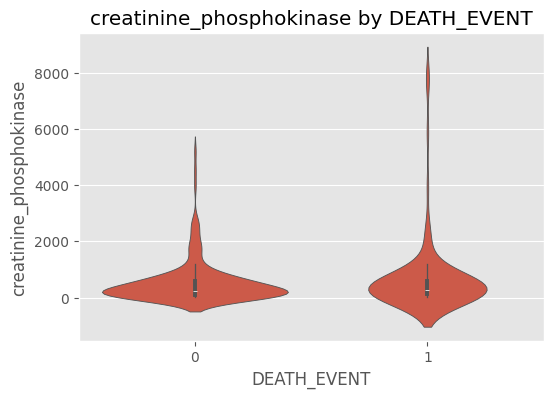

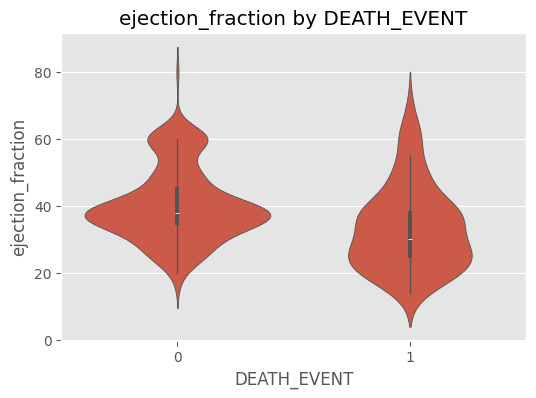

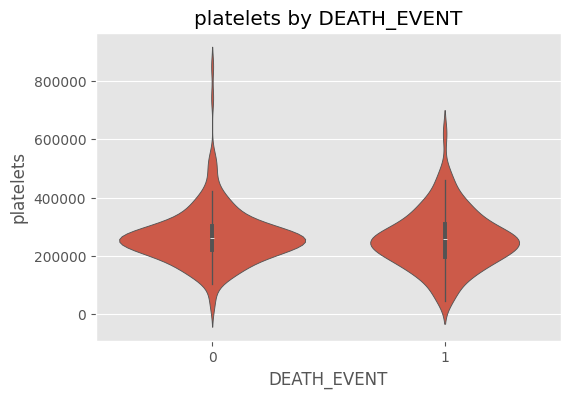

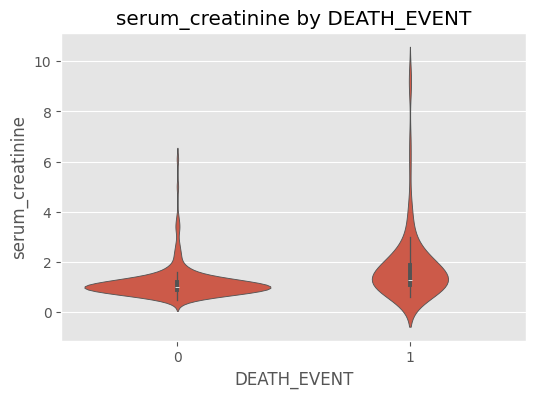

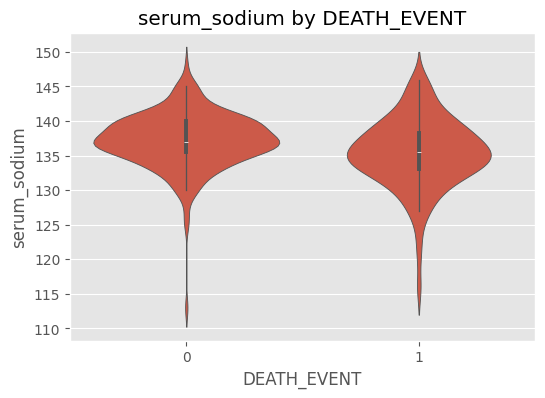

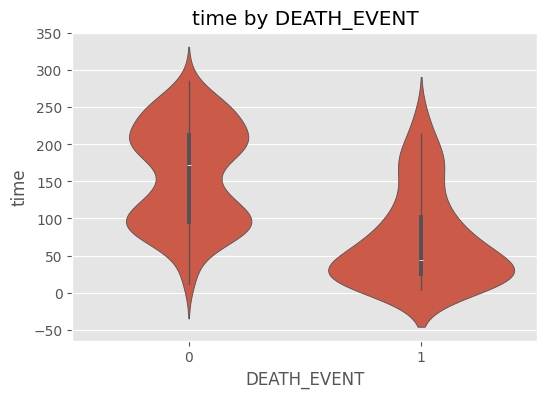

In [58]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.violinplot(
        x="DEATH_EVENT",
        y=col,
        data=df
    )

    plt.title(f"{col} by DEATH_EVENT")

    plt.show()

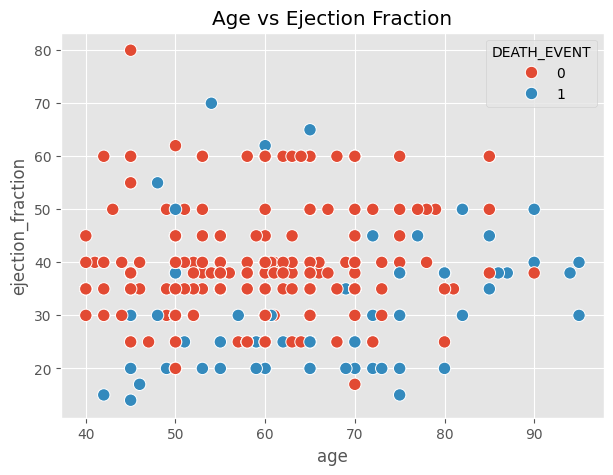

In [59]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="age",
    y="ejection_fraction",
    hue="DEATH_EVENT",
    s=80
)

plt.title("Age vs Ejection Fraction")
plt.show()

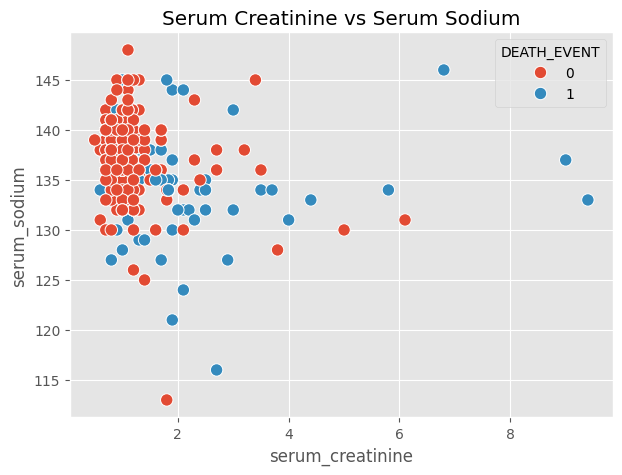

In [60]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="serum_creatinine",
    y="serum_sodium",
    hue="DEATH_EVENT",
    s=80
)

plt.title("Serum Creatinine vs Serum Sodium")
plt.show()

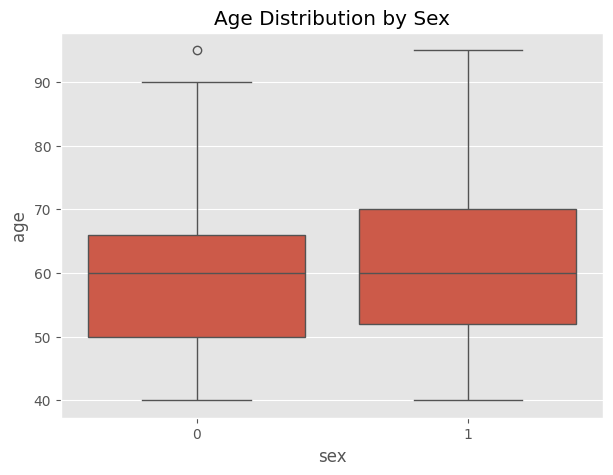

In [61]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="sex",
    y="age"
)

plt.title("Age Distribution by Sex")
plt.show()

In [62]:
group_means = df.groupby("DEATH_EVENT")[numerical_cols].mean().T

group_means

DEATH_EVENT,0,1
age,58.761906,65.215281
creatinine_phosphokinase,540.054187,670.197917
ejection_fraction,40.266010,33.468750
platelets,266657.489901,256381.044792
serum_creatinine,1.184877,1.835833
serum_sodium,137.216749,135.375000
time,158.339901,70.885417


In [63]:
group_means = df.groupby("DEATH_EVENT")[numerical_cols].mean().T

group_means

DEATH_EVENT,0,1
age,58.761906,65.215281
creatinine_phosphokinase,540.054187,670.197917
ejection_fraction,40.266010,33.468750
platelets,266657.489901,256381.044792
serum_creatinine,1.184877,1.835833
serum_sodium,137.216749,135.375000
time,158.339901,70.885417


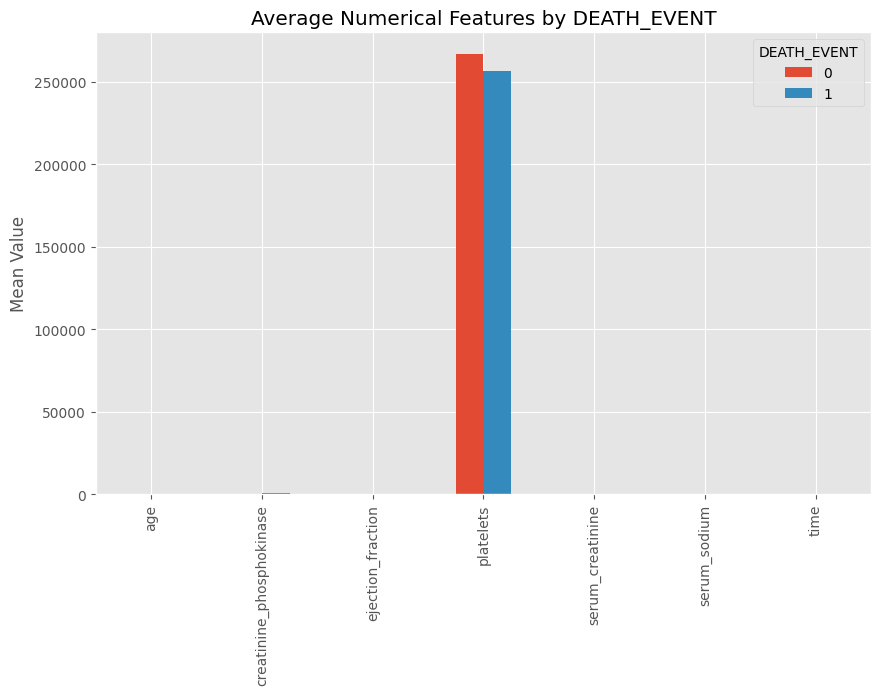

In [64]:
group_means.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Numerical Features by DEATH_EVENT")
plt.ylabel("Mean Value")

plt.show()

## Key Findings

- The dataset contains 299 patient records and 13 clinical variables.
- No missing values or duplicate records were identified.
- Several laboratory measurements, particularly creatinine phosphokinase and serum creatinine, exhibit right-skewed distributions and outliers.
- The target variable (DEATH_EVENT) is moderately imbalanced, with approximately 68% survivors and 32% deaths.
- Ejection fraction, serum creatinine, age, serum sodium, and follow-up time show the strongest relationships with mortality.
- No severe multicollinearity is present among predictor variables.
- Clinical features demonstrate meaningful but overlapping distributions, indicating that machine learning models leveraging multiple variables are likely to outperform single-feature analyses.